<a href="https://colab.research.google.com/github/SadiHassan/Learning-LLM-3L1M/blob/main/micrograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [45]:
def f(x):
  return 3*x**2 - 4*x + 5

In [46]:
f(3.0)

20.0

In [47]:
xs = np.arange(-5, 5, 0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [48]:
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

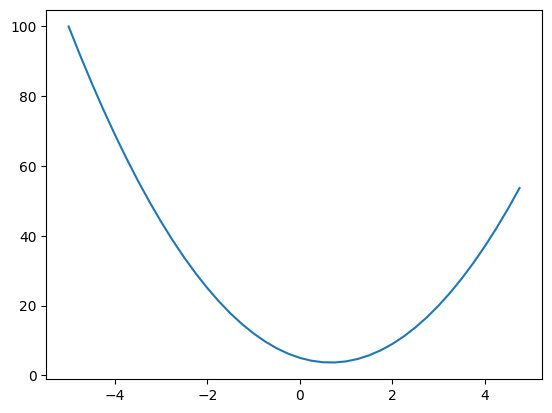

In [49]:
plt.plot(xs, ys)

In [50]:
h = 0.000001
x = 2/3
(f(x + h) - f(x))/h

2.999378523327323e-06

In [51]:
# les get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [52]:
def get_diff_for_x(a1, b1, c1):
  a, b, c = 2.0, -3.0, 10.0
  d1 = a * b + c

  a += a1
  b += b1
  c += c1
  d2 = a * b + c
  return d1, d2

In [53]:
h = 0.0001

d1, d2 = get_diff_for_x(h, 0, 0)
print('d1', d1)
print('d2', d2)
print(f'slope delta-a: {(d2 - d1)/h}\n')

d1, d2 = get_diff_for_x(0, h, 0)
print('d1', d1)
print('d2', d2)
print(f'slope delta-b: {(d2 - d1)/h}\n')

d1, d2 = get_diff_for_x(0, 0, h)
print('d1', d1)
print('d2', d2)
print(f'slope delta-c: {(d2 - d1)/h}\n')



d1 4.0
d2 3.999699999999999
slope delta-a: -3.000000000010772

d1 4.0
d2 4.0002
slope delta-b: 2.0000000000042206

d1 4.0
d2 4.0001
slope delta-c: 0.9999999999976694



In [54]:
class Value:
  def __init__(self, data, _children = (), _op = '', label=''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label
    self.grad = 0.0    # to store derivative of final output w.r.t this node

  # if we do not have __repr__ function, we will see some ugly object
  def __repr__(self):
    return f"Value(data={self.data} label={self.label})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')
    return out

a = Value(3, label='a')
b = Value(2, label='b')
print(a,b)
print(a + b) #Python will internally call like below
print(a.__add__(b))

print(a * b)
c = Value(4, label='c')

print(a * b + a * c)


Value(data=3 label=a) Value(data=2 label=b)
Value(data=5 label=)
Value(data=5 label=)
Value(data=6 label=)
Value(data=18 label=)


In [83]:
yy = a * b + c; yy.label='yy'

In [56]:
a

Value(data=3 label=a)

In [57]:
(a.__mul__(b)).__add__(c)

Value(data=10 label=)

In [58]:
e = a * b
e.label = 'e'
e

Value(data=6 label=e)

In [59]:
d = e + c
d.label = 'd'
d._prev

{Value(data=4 label=c), Value(data=6 label=e)}

In [60]:
d

Value(data=10 label=d)

In [61]:
d._prev

{Value(data=4 label=c), Value(data=6 label=e)}

In [62]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph

  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [63]:
trace(d)

({Value(data=10 label=d),
  Value(data=2 label=b),
  Value(data=3 label=a),
  Value(data=4 label=c),
  Value(data=6 label=e)},
 {(Value(data=2 label=b), Value(data=6 label=e)),
  (Value(data=3 label=a), Value(data=6 label=e)),
  (Value(data=4 label=c), Value(data=10 label=d)),
  (Value(data=6 label=e), Value(data=10 label=d))})

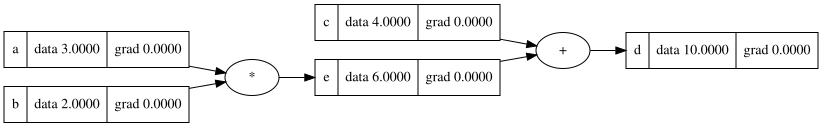

In [64]:
draw_dot(d)

In [65]:
f = Value(-2.0, label='f')
L = d * f
L.label = 'L'
L.grad = 1
L

Value(data=-20.0 label=L)

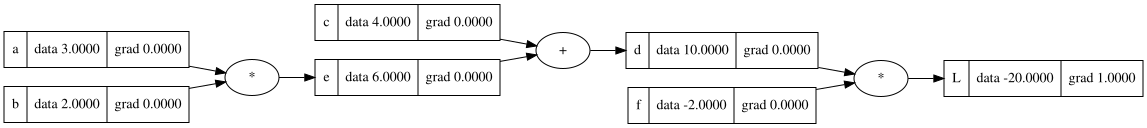

In [66]:
draw_dot(L)

In [67]:
print(1000000 * 2.9 / (3 * 12))

80555.55555555556


In [68]:
def lol():

  h = 0.001

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')

  b.data += h # increment b by h

  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L2 = L.data

  print((L2 - L1)/h)

lol()

-3.9999999999995595


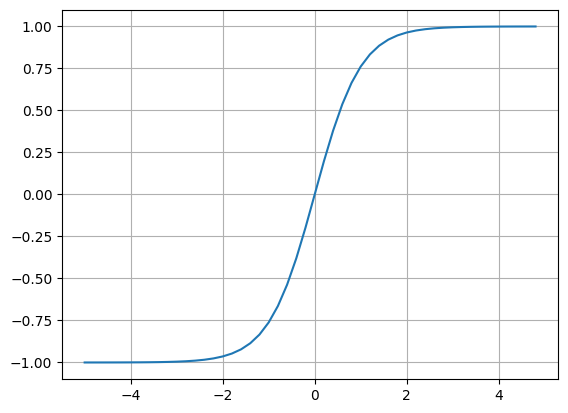

In [69]:
# tanh function
x = np.arange(-5, 5, 0.2)
y = np.tanh(x)
plt.plot(x, y); plt.grid()

Now, we will build this structure

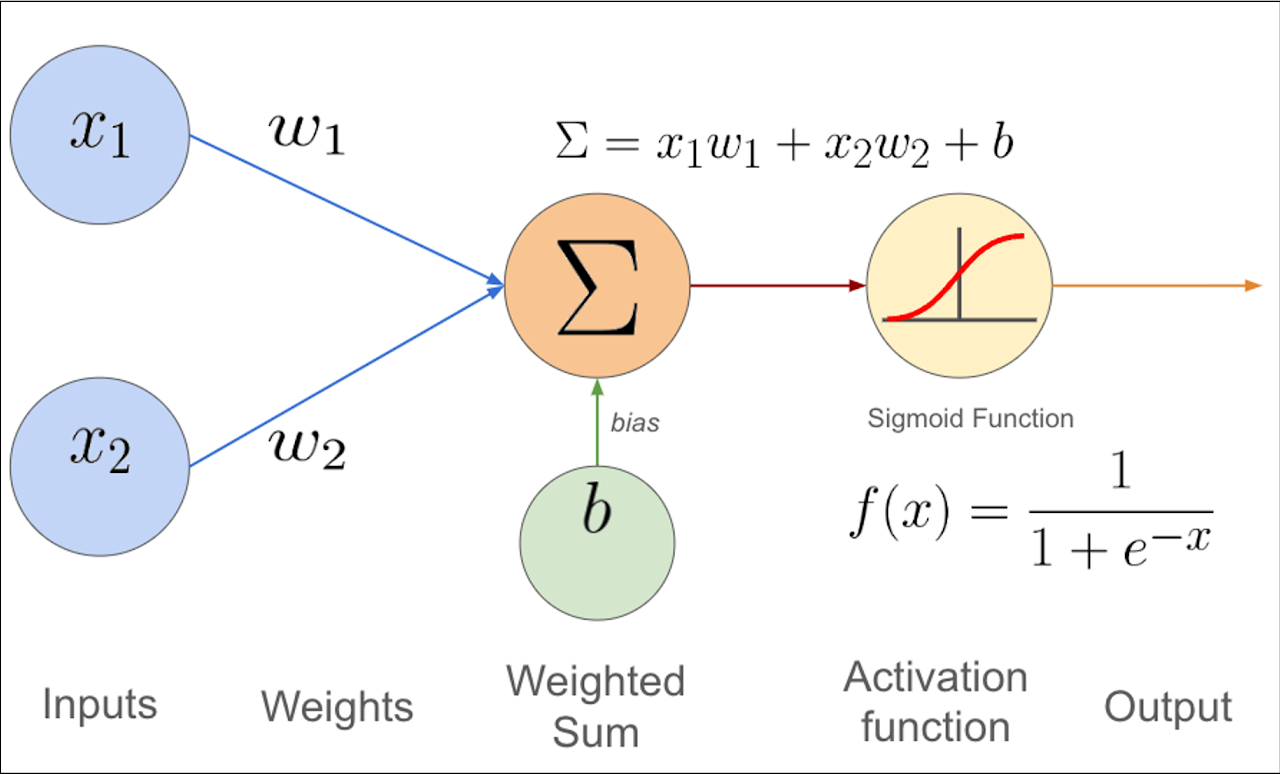

In [87]:
# inputs: x1 w1
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights: w1, w2
w1 = Value(-3.0, label='x1')
w2 = Value(1.0, label='x2')

# b = bias of the neuron
bb = Value(6.8813735870195432, label='bb')

# x1*w1 + x2*w2 + b
x1w1 = Value(x1*w1, label='x1w1')
x2w2 = Value(x2*w2, label='x1w1')

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
#n = Value((x1w1 + x2w2).data, label='n')
#n = x1w1x2w2; n.label='n'
n = x1w1x2w2 + Value(data=3.0, label='hudai'); n.label = 'n'
#o = n.tanh(); o.label = 'o'

AttributeError: 'float' object has no attribute 'data'